In [1]:
from sklearn.datasets import fetch_openml
print("Downloading MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, as_frame=True)
df = mnist.frame

print("MNIST dataset downloaded successfully.")

MNIST dataset downloaded successfully.


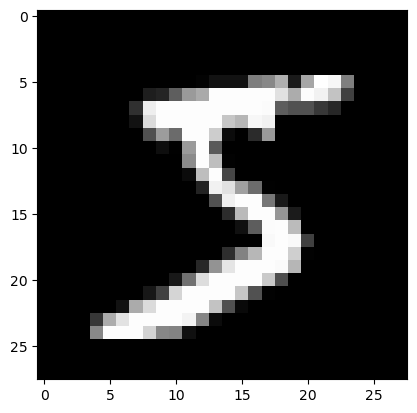

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

X = mnist.data

plt.imshow(X.iloc[0].values.reshape(28,28), cmap='gray')
plt.show()

In [3]:
import os 
import sys

root_dir = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if root_dir not in sys.path:
    sys.path.append(root_dir)

In [4]:
df.head()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,class
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9


In [ ]:
from preprocessing_util import extract_features_resnet_cnn


In [5]:
from sklearn.model_selection import train_test_split
y = df['class']
x = df.drop(columns=['class'])
x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.8)

In [7]:
from model import SVM_Multiclass

svm = SVM_Multiclass(x_train, y_train)
svm.train(epochs=10, learning_rate=0.01, regularization=0.1)
predictions = svm.predict(x_test)

Epoch 1/10 completed .......
Epoch 2/10 completed .......
Epoch 3/10 completed .......
Epoch 4/10 completed .......
Epoch 5/10 completed .......
Epoch 6/10 completed .......
Epoch 7/10 completed .......
Epoch 8/10 completed .......
Epoch 9/10 completed .......
Epoch 10/10 completed .......


In [18]:
print(predictions)
print(y_test)

[8 4 2 ... 6 4 2]
19065    8
64547    6
14510    2
35971    0
19433    7
        ..
26996    8
24305    9
55116    3
13418    4
58316    0
Name: class, Length: 14000, dtype: category
Categories (10, object): ['0', '1', '2', '3', ..., '6', '7', '8', '9']


In [ ]:
y_test_np = y_test.to_numpy(dtype=int)

correct_predictions = np.sum(predictions == y_test_np)
total_samples = len(y_test_np)
accuracy = correct_predictions / total_samples

print(f"Final Test Accuracy: {accuracy * 100:.2f}%")

Final Test Accuracy: 55.44%
